In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
 df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# Preprocessing

# Handling missing values

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature Engineering

In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [8]:
df["Age"] = 2026 - df["Year_Birth"]

In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

refrence_date = df["Dt_Customer"].max()

df["Customer_tenure_days"] = refrence_date - df["Dt_Customer"]
df["Customer_tenure_days"] = df["Customer_tenure_days"].dt.days

In [10]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [11]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [13]:
df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate" , "2n Cycle" : "Undergraduate",
    "PhD" : "Postgraduate" , "Master" : "Postgraduate"
})

In [14]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [15]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together" : "Partner",
    "Widow" : "Alone" , "Divorced" : "Alone" ,
    "Single" : "Alone" , "Absurd" : "Alone" , 
    "YOLO" : "Alone"
})

In [16]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [17]:
cols = ["ID" , "Year_Birth" ,  "Marital_Status" , "Kidhome" , "Teenhome" , "Dt_Customer" ]
spending_cols = ["MntWines" , "MntFruits" , "MntMeatProducts" , "MntGoldProds" , "MntSweetProducts" , "MntFishProducts" ]
col_to_drop = cols + spending_cols

In [18]:
df_cleaned = df.drop(columns = col_to_drop)

In [19]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [20]:
df_cleaned.shape

(2240, 15)

# Outlier handling

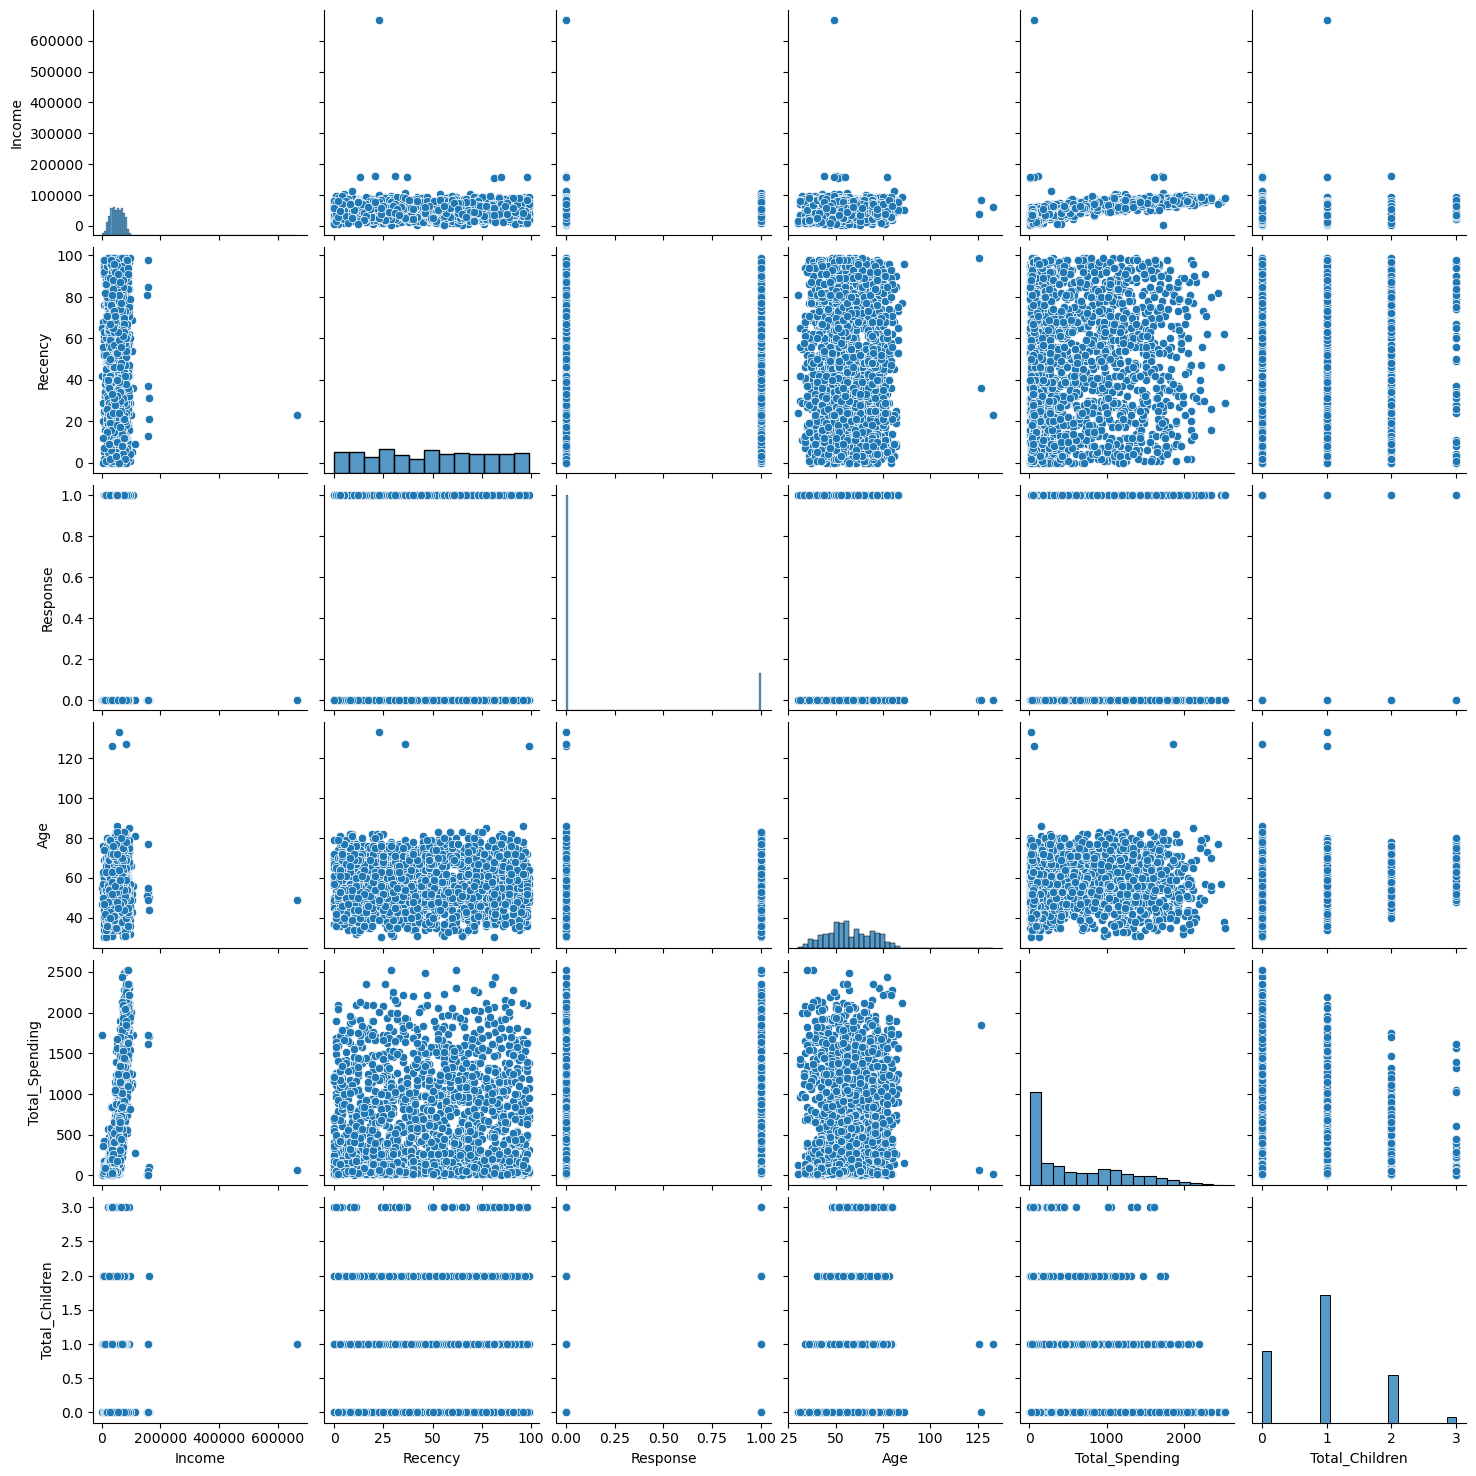

In [21]:
cols = ["Income", "Recency" , "Response" , "Age" , "Total_Spending" ,"Total_Children"]
sns.pairplot(df_cleaned[cols])

In [22]:
print("data with outliers :" , len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("data without outliers :" , len(df_cleaned))

data with outliers : 2240
data without outliers : 2236


In [23]:
print(df_cleaned["Age"].dtype)
print(df_cleaned["Income"].dtype)

int64
float64


# Correlation Heatmap

In [24]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

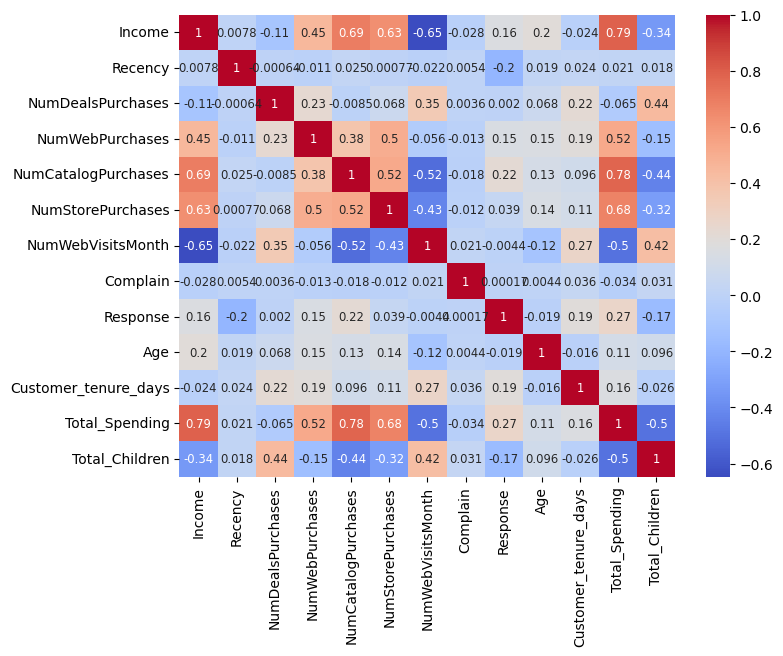

In [25]:
plt.figure(figsize = (8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":"small"},
    cmap = "coolwarm"
     
    
)

# Encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder
cat_cols = ["Education" , "Living_With"]
ohe = OneHotEncoder()
encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [27]:
enc_df = pd.DataFrame(encoded_cols.toarray(),columns = ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

In [28]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols) , enc_df],axis = 1)

# Scaling

In [29]:
X = df_encoded
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# visualization

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D projection')

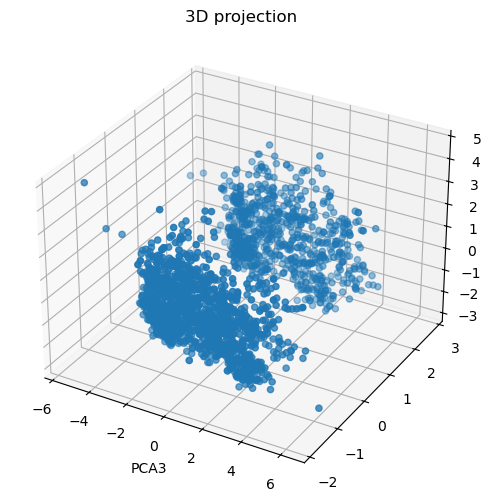

In [31]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2])
ax.set_xlabel("PCA1")
ax.set_xlabel("PCA2")
ax.set_xlabel("PCA3")
ax.set_title("3D projection")

# Analyse the k value

In [54]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1,11):
    model = KMeans(n_clusters = k , random_state = 42)
    model.fit_predict(X_pca)
    wcss.append(model.inertia_)

Text(0, 0.5, 'wcss')

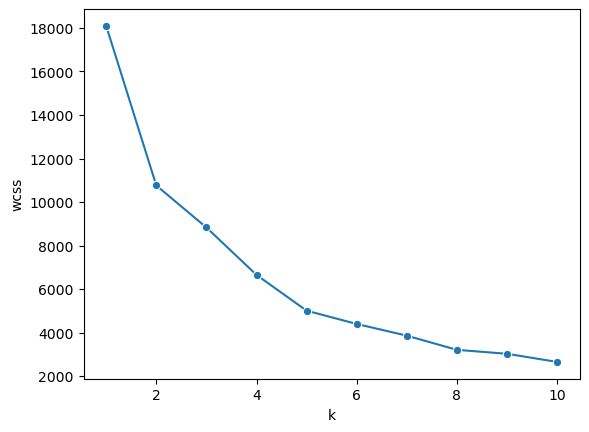

In [63]:
sns.lineplot(x = range(1,11) , y = wcss , marker = "o" )
plt.xlabel("k")
plt.ylabel("wcss")

In [64]:
from kneed import KneeLocator
knee = KneeLocator(range(1,11) , wcss , curve = "convex" , direction = "decreasing")
print(knee.elbow)

4


# Silhouette score

Text(0, 0.5, 'silhoutte scores')

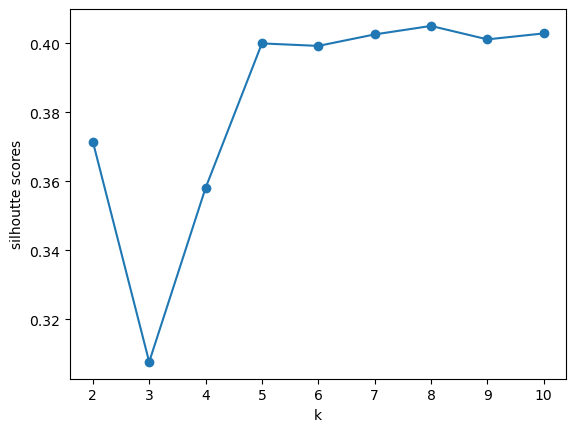

In [65]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score)

plt.plot(range(2,11) , scores , marker = "o")
plt.xlabel("k")
plt.ylabel("silhoutte scores")

Text(0, 0.5, 'ss')

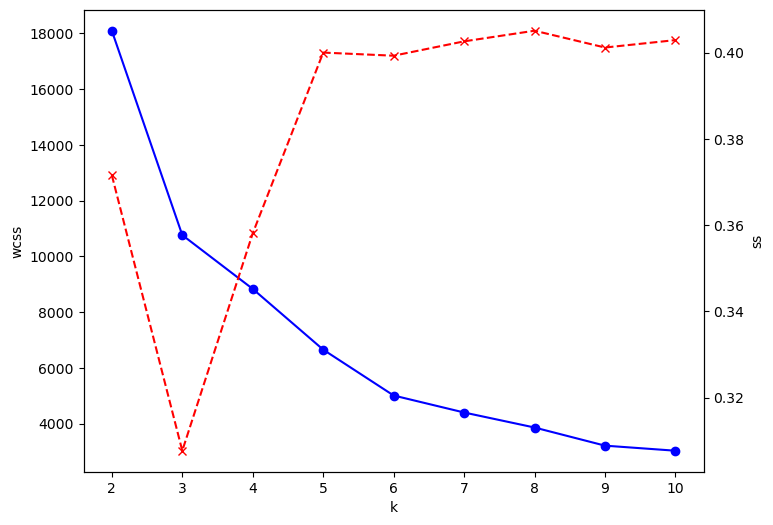

In [73]:
 #combined plot
k_range = range(2,11)
fig , ax1 = plt.subplots(figsize = (8,6))
ax1.plot (k_range , wcss[:len(k_range)] , marker = "o" , color = "blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2 = ax1.twinx()
ax2.plot(k_range , scores[:len(k_range)] , marker = "x" , color = "red" , linestyle = "--")
ax2.set_ylabel("ss")

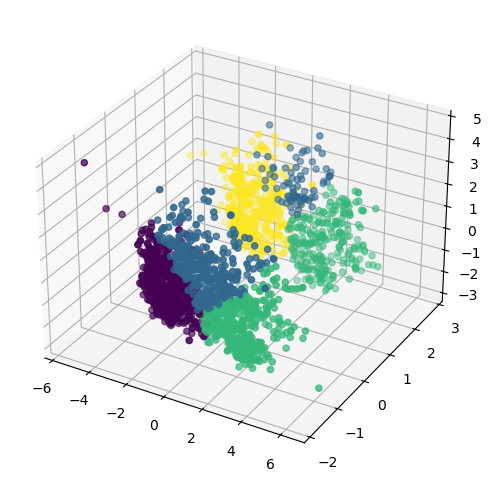

In [78]:
kmeans = KMeans(n_clusters = 4 , random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2], c = labels_kmeans)

In [81]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters = 4 , linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)

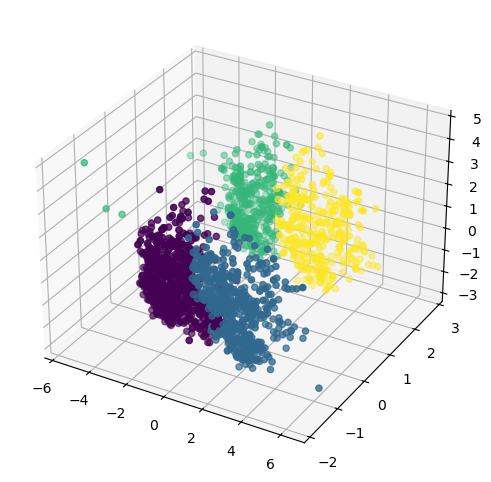

In [82]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(X_pca[: , 0] , X_pca[: , 1] , X_pca[: , 2], c = labels_agg)

# characterization of clusters


In [95]:
X["clusters"] = labels_agg

<Axes: xlabel='clusters', ylabel='count'>

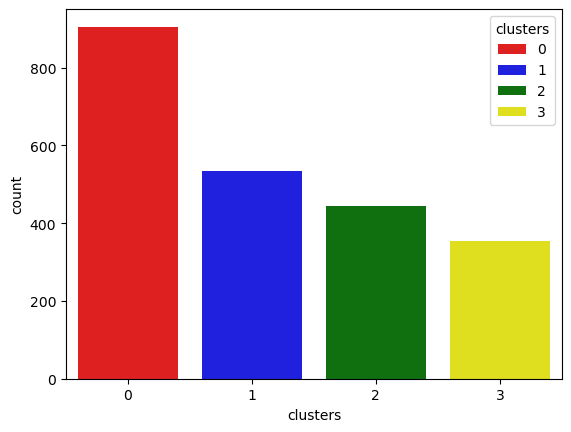

In [96]:
pal = ["red" , "blue" , "green" , "yellow"]
sns.countplot(x = X["clusters"] , palette = pal , hue = X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

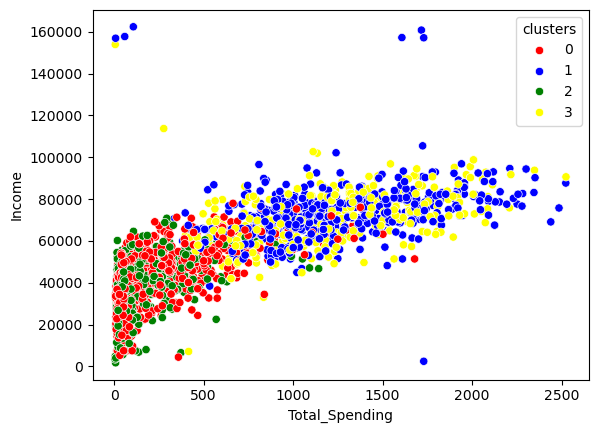

In [97]:
sns.scatterplot( x = X["Total_Spending"] , y = X["Income"] , hue = X["clusters"] , palette = pal)

In [98]:
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenure_days  Total_Spending  \
clu